In [46]:
from typing import TypedDict, List
import time
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END

load_dotenv()

True

In [35]:
docs=(
    PyPDFLoader("./documents/book1.pdf").load()
)

In [36]:
len(docs)

758

In [37]:
chunks=RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)
for d in chunks:
    d.page_content=d.page_content.encode('utf-8', "ignore").decode('utf-8', "ignore")

In [38]:
len(chunks)

2465

In [41]:
embedding=OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore=FAISS.from_documents(chunks, embedding)

In [43]:
retriever=vectorstore.as_retriever(search_type="similarity", search_kwargs={"k":4})

In [44]:
llm=ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [50]:
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str

In [57]:
def retriever_docs(state: State) -> State:
    q=state["question"]
    return {"docs": retriever.invoke(q)}

In [58]:
prompt=ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. if not in context, say you don't know"),
        ("human", "Question: {question}\n\nContext: \n{context}"),
    ]
)
def generate(state: State)-> State:
    context= "\n\n".join(d.page_content for d in state["docs"])
    out = (prompt | llm).invoke({"question": state["question"], "context": context})
    return {"answer": out.content}

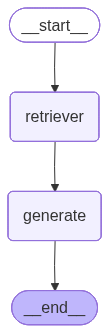

In [62]:
g=StateGraph(State)
g.add_node("retriever", retriever_docs)
g.add_node("generate", generate)
g.add_edge(START, "retriever")
g.add_edge("retriever", "generate")
g.add_edge("generate", END)
app=g.compile()
app

In [63]:
result= app.invoke({"question": "what is transformers in deep learning?", "docs":[], "answer": ""})
print(result)

AttributeError: 'function' object has no attribute 'invoke'